# PCA Using MNIST Dataset


The MNIST dataset is a widely used benchmark in machine learning for handwritten digit recognition. It consists of 70,000 grayscale images of size 28x28 pixels, divided into 60,000 training images and 10,000 testing images. Each image represents a digit (0-9), making it a 10-class classification problem.
PyTorch provides a convenient way to load and preprocess the MNIST dataset using the torchvision.datasets.MNIST class. Below is an example of how to load and visualize the dataset.

In [15]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [16]:
# Define transformations: Convert images to tensors
transform = transforms.Compose([transforms.ToTensor()])
# Load the MNIST dataset
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)



In [17]:
#To access and demonstrate the data in the training dataset
print(mnist_train.data[0])
print(mnist_test.data[0].shape)

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

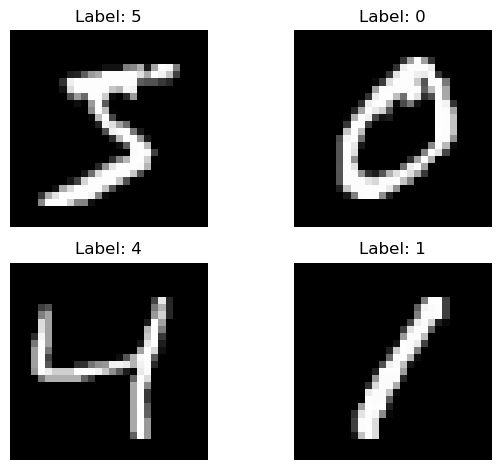

In [18]:
# Display sample images from training set
fig, axes = plt.subplots(2, 2)
for i, ax in enumerate(axes.flat):
    ax.imshow(mnist_train.data[i].numpy(), cmap='gray')
    ax.set_title(f'Label: {mnist_train.targets[i].item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()

Since one image is a [28, 28] matrix, we need to flatten it into 1D array to conduct PCA.

In [19]:
import numpy as np

# Flatten images: convert [28, 28] to 784 features
#/255.0: Convert the gray scale from [0,255] to [0,1]
X_train = mnist_train.data.reshape(len(mnist_train), -1).float() /255.0
X_test = mnist_test.data.reshape(len(mnist_test), -1).float() /255.0

# Convert PyTorch tensors to NumPy arrays
X_train = X_train.numpy()
X_test = X_test.numpy()
X_train.shape



(60000, 784)

We randomly select some data from the original dataset to speed up the PCA process.

In [20]:

# Sample 2000 data points from the original dataset
sample_size = 2000
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)
X_sample = X_train[sample_indices]
y_sample = mnist_train.targets.numpy()[sample_indices]
X_sample.shape

(2000, 784)

In [21]:
X= X_sample
y= y_sample

### Singular Value Decomposition


<br>For the SVD here: $$X / cov(X) = U.S.V^*$$

In practice, you can also do SVD on X directly, as the eigenvalues of cov are squared compared to X. So, it is numerically more stable especially when data dimension is very large. But here we've got an acceptable size of 784. So, we use the cov matrix.

S is a diagonal matrix and U is a unitary matrix whose columns are exactly the u vectors we want.  Actually, u vectors signify the new planes to which we will project our data sample.<br> <br>Therefore, to reduce a system from n-dimensions to k-dimensions, just take the first k-vectors from U (first k columns).




### Covariance Matrix

The first step in PCA is establishing the covariance matrix of the design matrix.Covariance measures how variables vary together relative to their mean, not relative to the origin (0,0). The covariance matrix formula is: 
$$cov(X) = \frac{1}{n-1}(X - \bar{X})^T(X - \bar{X}).$$
 So the centering of data is automatically done in the step of getting the covariance matrix.

In [22]:
cov = np.cov(X,rowvar=False)

In [23]:

#Conduct SVD on the covariance matrix
from numpy import linalg as la
U,sigma,VT=la.svd(cov)
print(sigma)
print(U.shape)
#print(U)


[5.01806978e+00 3.69850873e+00 3.07194619e+00 2.93099868e+00
 2.66618154e+00 2.29479474e+00 1.73360277e+00 1.55402888e+00
 1.49157313e+00 1.25030507e+00 1.12433150e+00 1.04986827e+00
 9.27867538e-01 8.94978612e-01 8.55240272e-01 7.92276949e-01
 7.02750402e-01 6.70132462e-01 6.26517388e-01 6.00711575e-01
 5.85082531e-01 5.52157758e-01 5.21095497e-01 4.89929392e-01
 4.53927927e-01 4.44520854e-01 4.37502188e-01 4.16378892e-01
 4.00513842e-01 3.58624090e-01 3.49610508e-01 3.47043466e-01
 3.25678142e-01 3.09504335e-01 3.00253641e-01 2.84880014e-01
 2.77978903e-01 2.67646260e-01 2.54722710e-01 2.46136382e-01
 2.43965521e-01 2.31704266e-01 2.19130445e-01 2.17314706e-01
 2.04183359e-01 2.01863913e-01 1.98620670e-01 1.83807466e-01
 1.80050561e-01 1.76877353e-01 1.67092641e-01 1.64013863e-01
 1.59198112e-01 1.54981599e-01 1.51111383e-01 1.44303029e-01
 1.40084661e-01 1.37538949e-01 1.33405103e-01 1.29035322e-01
 1.27000949e-01 1.24475145e-01 1.24267225e-01 1.19576999e-01
 1.16987786e-01 1.105448

### Principal Components

To get the reduced system is to transform every x of example in design matrix X into z, which is: 
$$X_{reduced}(2000 \times D)=X(2000 \times 784)\cdot U_{reduced} (784 \times D).$$

So, we design a function here to get the reduced system and also show the ratio of information(variance) kept.

In [24]:
def reduce_system(U, dimension):
    # Step 1: Extract the first 'dimension' principal components
    U_reduced = U[:, :dimension]
    
    # Step 2: Project original data onto the reduced space
    reduced_vec = np.dot(X, U_reduced)
    
    # Step 3: Calculate variance explained as a ratio
    var = np.sum(sigma[:dimension]) / np.sum(sigma[:])
    
    return reduced_vec, var

### Variance vs Reduced Dimension

We can plot the variance loss against the dimensions.

In [25]:
dimensions = []
variance = []
for i in range(16):
    reducevec, var_i = reduce_system(U,i*50)
    dimensions.append(i*50)
    variance.append(var_i)

Text(0.5, 1.0, 'Dimensions vs variance')

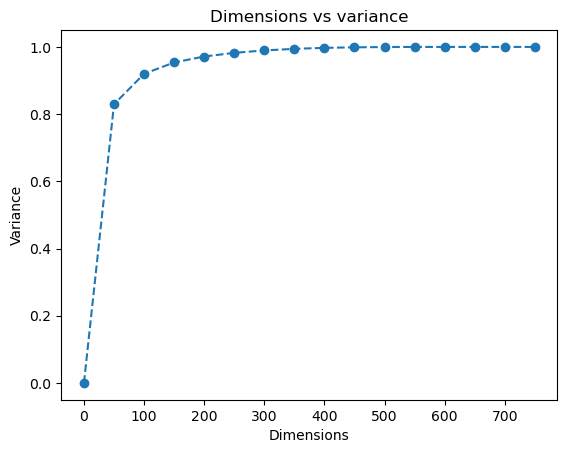

In [26]:
plt.plot(dimensions,variance,marker='o',ls='--')
plt.xlabel("Dimensions")
plt.ylabel("Variance")
plt.title("Dimensions vs variance")

### Comparison Between Recovered and Initial Data

To get the recovered data:
$$X_{recovered}(2000 \times 784)=X_{reduced}(2000 \times D)\cdot U_{reduced}^T (D \times 784).$$

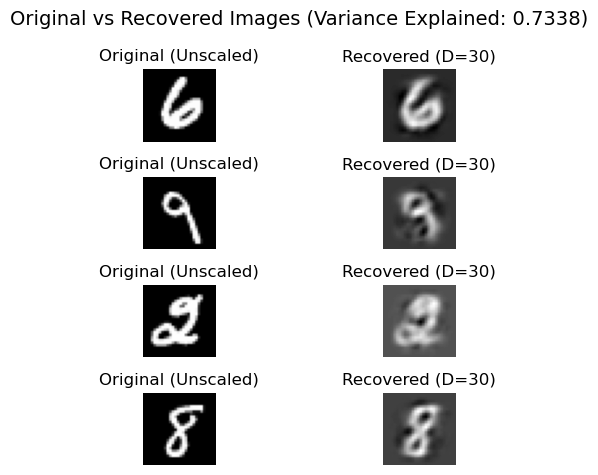

Mean Squared Error: 0.022492
Variance Explained with 30 components: 0.7338


In [27]:
# Recover the matrix and compare original vs recovered images
num_examples = 4
dimension = 30  # Try different values: 10, 20, 50, 100, 200, 500 to see the effect

# Get reduced data and variance using reduce_system
X_reduced, variance_explained = reduce_system(U, dimension)

# Create U_reduced for reconstruction
U_reduced = U[:, :dimension]

# Recover the data from the reduced representation (in scaled space)
X_recovered = np.dot(X_reduced, U_reduced.T)

# Compare with original unscaled data
X_original_samples = X_sample[:num_examples]
X_recovered_samples = X_recovered[:num_examples]

# Visualize original vs recovered images with difference
fig, axes = plt.subplots(num_examples, 2)

for i in range(num_examples):
    # Original unscaled image
    orig_img = X_original_samples[i].reshape(28, 28)
    axes[i, 0].imshow(orig_img, cmap='gray')
    axes[i, 0].set_title(f'Original (Unscaled)')
    axes[i, 0].axis('off')
    
    # Recovered image (inverse-transformed back to original scale)
    rec_img = X_recovered_samples[i].reshape(28, 28)
    axes[i, 1].imshow(rec_img, cmap='gray')
    axes[i, 1].set_title(f'Recovered (D={dimension})')
    axes[i, 1].axis('off')
    


plt.suptitle(f'Original vs Recovered Images (Variance Explained: {variance_explained:.4f})', fontsize=14)
plt.tight_layout()
plt.show()

# Print reconstruction error
mse = np.mean((X_original_samples - X_recovered_samples) ** 2)
print(f"Mean Squared Error: {mse:.6f}")
print(f"Variance Explained with {dimension} components: {variance_explained:.4f}")